# Notebook 2 - Analyse approfondie de la chaine BIMO (YouTube Studio)
## Niveau 2 : Audit complet de l'audience reelle

**Objectif :** Analyser en detail les performances de la chaine BIMO
a partir des donnees exportees depuis YouTube Studio, pour comprendre
ce que l'audience de BIMO aime, quand elle regarde, d'ou elle vient,
et quelles videos surperforment.

**Fichiers utilises :**
- `Informations_relatives_aux_tableaux.csv` - stats par video (fichier principal)
- `Age_du_spectateur_genre.csv` - demographie de l'audience
- `source_de_trafic.csv` - sources de trafic aggregees
- `Informations_relatives_aux_tableaux_Situation_geographique_.csv` - performance par pays

**Structure :**
1. Import et nettoyage
2. Feature engineering
3. Vue d'ensemble de la chaine
4. Analyse de l'audience (age, genre, geo)
5. Analyse des sources de trafic
6. Analyse temporelle (mois, jour, annee)
7. Performance par format de duree
8. CTR et retention - drivers de succes
9. Top et bottom performers
10. Analyse Ramadan
11. Synthese et recommandations


## 0. Imports et configuration

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import mannwhitneyu, spearmanr
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize']   = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("Imports OK")


Imports OK


## 1. Import et nettoyage des donnees

### 1.1 Chargement des 4 fichiers

In [73]:
from pathlib import Path

df_videos = pd.read_csv("Informations relatives aux tableaux.csv",          encoding="utf-8")
df_age    = pd.read_csv("Age du spectateur_genre.csv",                          encoding="utf-8")
df_trafic = pd.read_csv("source de trafic.csv",                                 encoding="utf-8")
df_geo    = pd.read_csv("Informations relatives aux tableaux(Situation géographique).csv", encoding="utf-8")

# Supprimer la ligne Total du fichier principal
df = df_videos[df_videos['Contenu'] != 'Total'].copy()
df.columns = [c.strip() for c in df.columns]

print(f"Videos chargees      : {len(df)}")
print(f"Sources de trafic    : {len(df_trafic) - 1}")
print(f"Pays analyses        : {len(df_geo) - 1}")
print(f"Tranches age/genre   : {len(df_age)}")


Videos chargees      : 450
Sources de trafic    : 20
Pays analyses        : 112
Tranches age/genre   : 21


### 1.2 Nettoyage et types

In [74]:
# Parse date de publication
df['pub_date'] = pd.to_datetime(df['Heure de publication de la vidéo'], errors='coerce')
df['pub_year']  = df['pub_date'].dt.year
df['pub_month'] = df['pub_date'].dt.month
df['pub_month_name'] = df['pub_date'].dt.strftime('%b')
df['pub_dow']   = df['pub_date'].dt.dayofweek
df['pub_day_name'] = df['pub_date'].dt.strftime('%A')

# Parse duree moyenne d'une vue (format MM:SS ou HH:MM:SS) -> secondes
def parse_duration_str(s):
    if pd.isna(s): return np.nan
    parts = str(s).strip().split(':')
    try:
        if len(parts) == 3:
            return int(parts[0])*3600 + int(parts[1])*60 + int(parts[2])
        elif len(parts) == 2:
            return int(parts[0])*60 + int(parts[1])
    except:
        return np.nan

df['avg_view_sec'] = df["Durée moyenne d'une vue"].apply(parse_duration_str)

# Filtre : on garde uniquement 2020+ (videos avec donnees fiables)
df_all = df.copy()
df = df[df['pub_year'] >= 2020].copy()

print(f"Videos 2020+ retenues : {len(df)} / {len(df_all)}")
print(f"Periode : {df['pub_date'].min().date()} -> {df['pub_date'].max().date()}")
print()
print("Completude des colonnes cles :")
cols_check = {
    'Vues'                                      : 'Vues',
    'Taux de clics par impression (%)'          : 'CTR',
    'Pourcentage moyen de video regarde (%)'    : 'Retention',
    'Durée de visionnage (heures)'              : 'Watch time',
    'Abonnes'                                   : 'Abonnes gagnes',
    'avg_view_sec'                              : 'Duree vue moy (sec)',
    'Durée'                                     : 'Duree video (sec)',
    'Ont continué de regarder (%)'              : 'Ont continue (%)',
}
for col, label in cols_check.items():
    if col in df.columns:
        n   = df[col].notna().sum()
        pct = n / len(df) * 100
        flag = "  <- a gerer" if pct < 80 else ""
        print(f"  {label:<30} : {n:>3}/{len(df)} ({pct:.0f}%){flag}")


Videos 2020+ retenues : 372 / 450
Periode : 2020-01-06 -> 2026-04-08

Completude des colonnes cles :
  Vues                           : 372/372 (100%)
  CTR                            : 372/372 (100%)
  Watch time                     : 372/372 (100%)
  Duree vue moy (sec)            : 372/372 (100%)
  Duree video (sec)              : 372/372 (100%)
  Ont continue (%)               : 231/372 (62%)  <- a gerer


In [92]:
df_videos.columns

Index(['Contenu', 'Titre de la vidéo', 'Heure de publication de la vidéo',
       'Durée', 'Pourcentage moyen de vidéo regardé (%)',
       'Durée moyenne d'une vue', 'Ont continué de regarder (%)', 'Vues',
       'Durée de visionnage (heures)', 'Abonnés', 'Impressions',
       'Taux de clics par impression (%)'],
      dtype='object')

In [93]:
df_age.columns


Index(['Âge du spectateur', 'Genre du spectateur', 'Vues (%)',
       'Durée de visionnage (heures) (%)'],
      dtype='object')

In [94]:
df_trafic.columns


Index(['Source de trafic', 'Durée moyenne d'une vue',
       'Pourcentage moyen de vidéo regardé (%)', 'Vues',
       'Durée de visionnage (heures)', 'Impressions',
       'Taux de clics par impression (%)'],
      dtype='object')

In [96]:
df_geo.columns

Index(['Situation géographique', 'Durée moyenne d'une vue', 'J'aime',
       'Je n'aime pas', '% "J'aime" (%)', 'Vues',
       'Durée de visionnage (heures)', 'Abonnés', 'Revenus estimés (MAD)'],
      dtype='object')

## 2. Feature engineering

In [75]:
# Categories de duree video
def categorize_duration(sec):
    if pd.isna(sec):         return 'Inconnu'
    if sec < 300:            return 'Court (0-5min)'
    elif sec < 900:          return 'Moyen (5-15min)'
    elif sec < 1800:         return 'Long (15-30min)'
    else:                    return 'Tres long (30min+)'

df['dur_cat'] = df['Durée'].apply(categorize_duration)

# Tiers de performance (tertiles de vues)
q33 = df['Vues'].quantile(0.33)
q66 = df['Vues'].quantile(0.66)
def perf_tier(v):
    if v >= q66:   return 'Top'
    elif v >= q33: return 'Moyen'
    else:          return 'Faible'
df['perf_tier'] = df['Vues'].apply(perf_tier)

# Flag Ramadan
ramadan_periods = [
    ('2020-04-24','2020-05-23'), ('2021-04-12','2021-05-11'),
    ('2022-04-02','2022-05-01'), ('2023-03-22','2023-04-20'),
    ('2024-03-11','2024-04-09'), ('2025-03-01','2025-03-29'),
]
df['is_ramadan'] = False
for s, e in ramadan_periods:
    mask = (df['pub_date'] >= pd.Timestamp(s)) & (df['pub_date'] <= pd.Timestamp(e))
    df.loc[mask, 'is_ramadan'] = True

# Saison
def get_saison(m):
    if m in [12,1,2]:  return 'Hiver'
    elif m in [3,4,5]: return 'Printemps'
    elif m in [6,7,8]: return 'Ete'
    else:              return 'Automne'
df['saison'] = df['pub_month'].apply(get_saison)

# CTR categories
df['ctr_cat'] = pd.cut(
    df['Taux de clics par impression (%)'],
    bins=[0,3,5,7,10,100],
    labels=['Faible (<3%)','Correct (3-5%)','Bon (5-7%)','Tres bon (7-10%)','Excellent (>10%)']
)

print("Features crees :")
print(f"  dur_cat     : {df['dur_cat'].value_counts().to_dict()}")
print(f"  perf_tier   : {df['perf_tier'].value_counts().to_dict()}")
print(f"  is_ramadan  : {df['is_ramadan'].sum()} videos en Ramadan")
print(f"  saison      : {df['saison'].value_counts().to_dict()}")
print(f"  Seuils perf -> Faible: <{q33:,.0f} | Top: >{q66:,.0f} vues")


Features crees :
  dur_cat     : {'Moyen (5-15min)': 294, 'Long (15-30min)': 67, 'Court (0-5min)': 7, 'Tres long (30min+)': 4}
  perf_tier   : {'Top': 127, 'Faible': 123, 'Moyen': 122}
  is_ramadan  : 34 videos en Ramadan
  saison      : {'Printemps': 98, 'Hiver': 96, 'Ete': 94, 'Automne': 84}
  Seuils perf -> Faible: <596,437 | Top: >915,105 vues


## 3. Vue d'ensemble de la chaine

### 3.1 Statistiques globales

In [76]:
cols_stats = [
    'Vues', 'Durée de visionnage (heures)', 'Abonnés',
    'Impressions', 'Taux de clics par impression (%)',
    'Pourcentage moyen de vidéo regardé (%)', 'avg_view_sec', 'Durée'
]
df[cols_stats].describe().round(2)


,Vues,Durée de visionnage (heures),Abonnés,Impressions,Taux de clics par impression (%),Pourcentage moyen de vidéo regardé (%),avg_view_sec,Durée
count,372.00,372.00,372.00,372.00,372.00,372.00,372.00,372.00
mean,831730.83,89011.36,4335.01,9007640.07,6.66,52.31,366.80,722.60
std,416662.90,59097.92,5218.25,5326688.21,1.09,6.49,115.47,311.90
min,126543.00,3361.02,10.00,910594.00,2.97,30.37,40.00,60.00
25%,528082.75,47469.93,1483.00,5040987.00,5.99,48.36,298.50,535.75
50%,752612.50,75090.65,2812.00,7746879.50,6.64,52.60,348.00,642.00
75%,1069155.50,111221.86,4891.00,11413194.00,7.30,56.93,414.00,836.50
max,2680854.00,324671.54,53788.00,36357618.00,11.46,69.32,1178.00,3707.00


### 3.2 Metriques cumulees de la chaine

In [77]:
totaux = {
    'Total vues (M)'           : df['Vues'].sum() / 1e6,
    'Watch time total (k heures)': df['Durée de visionnage (heures)'].sum() / 1e3,
    'Total abonnes gagnes (k)' : df['Abonnés'].sum() / 1e3,
    'Total impressions (M)'    : df['Impressions'].sum() / 1e6,
    'CTR median (%)'           : df['Taux de clics par impression (%)'].median(),
    'Retention mediane (%)'    : df['Pourcentage moyen de vidéo regardé (%)'].median(),
    'Duree vue mediane (min)'  : df['avg_view_sec'].median() / 60,
}
for label, val in totaux.items():
    print(f"  {label:<35} : {val:.2f}")


  Total vues (M)                      : 309.40
  Watch time total (k heures)         : 33112.23
  Total abonnes gagnes (k)            : 1612.62
  Total impressions (M)               : 3350.84
  CTR median (%)                      : 6.64
  Retention mediane (%)               : 52.60
  Duree vue mediane (min)             : 5.80


### 3.3 Evolution annuelle de la chaine

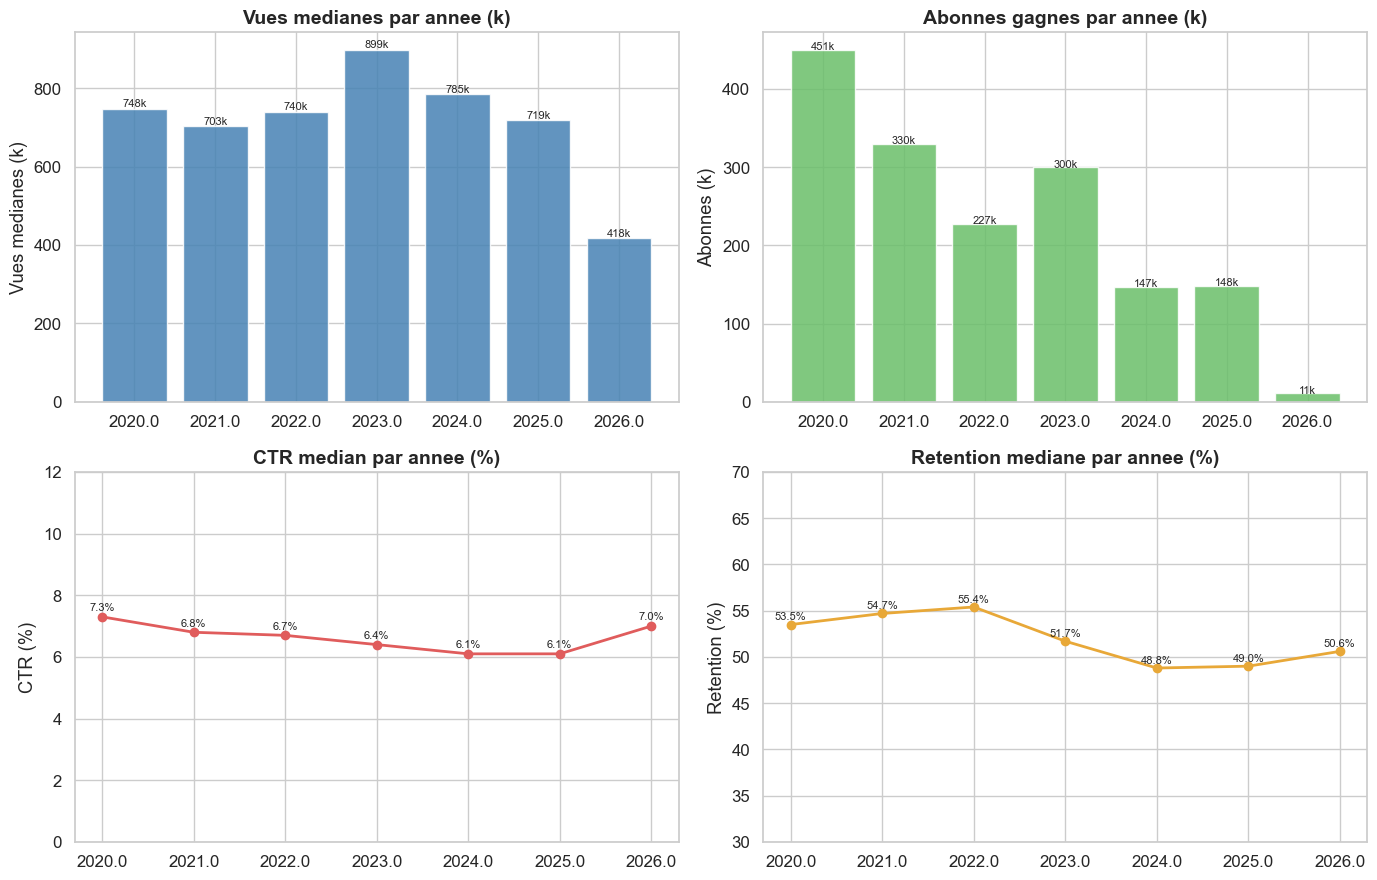

In [78]:
yr = df.groupby('pub_year').agg(
    nb_videos=('Vues',     'count'),
    vues_med=('Vues',      'median'),
    ctr_med=('Taux de clics par impression (%)', 'median'),
    ret_med=('Pourcentage moyen de vidéo regardé (%)', 'median'),
    abonnes_total=('Abonnés', 'sum'),
    watch_total=('Durée de visionnage (heures)', 'sum')
).round(1)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Vues medianes
axes[0,0].bar(yr.index.astype(str), yr['vues_med']/1e3, color='steelblue', alpha=0.85)
axes[0,0].set_title("Vues medianes par annee (k)")
axes[0,0].set_ylabel("Vues medianes (k)")
for bar, v in zip(axes[0,0].patches, yr['vues_med']):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                   f"{v/1e3:.0f}k", ha='center', fontsize=8)

# Abonnes gagnes
axes[0,1].bar(yr.index.astype(str), yr['abonnes_total']/1e3, color='#6ABF69', alpha=0.85)
axes[0,1].set_title("Abonnes gagnes par annee (k)")
axes[0,1].set_ylabel("Abonnes (k)")
for bar, v in zip(axes[0,1].patches, yr['abonnes_total']):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                   f"{v/1e3:.0f}k", ha='center', fontsize=8)

# CTR evolution
axes[1,0].plot(yr.index.astype(str), yr['ctr_med'], 'o-', color='#e05c5c', lw=2)
axes[1,0].set_title("CTR median par annee (%)")
axes[1,0].set_ylabel("CTR (%)")
axes[1,0].set_ylim(0, 12)
for x, y in zip(yr.index.astype(str), yr['ctr_med']):
    axes[1,0].text(x, y+0.2, f"{y:.1f}%", ha='center', fontsize=8)

# Retention evolution
axes[1,1].plot(yr.index.astype(str), yr['ret_med'], 'o-', color='#e8a838', lw=2)
axes[1,1].set_title("Retention mediane par annee (%)")
axes[1,1].set_ylabel("Retention (%)")
axes[1,1].set_ylim(30, 70)
for x, y in zip(yr.index.astype(str), yr['ret_med']):
    axes[1,1].text(x, y+0.5, f"{y:.1f}%", ha='center', fontsize=8)

plt.tight_layout()
plt.show()


**Lecture des resultats :**

- **2020 est l'annee de rupture** : avant 2020, les vues medianes etaient quasi nulles (moins de 1k). A partir de 2020 BIMO s'installe durablement au-dessus de 650k vues medianes par video.
- **Le pic de CTR est en 2019-2020** (7.3-7.6%) puis il baisse progressivement jusqu'en 2024-2025 (6.1%). Cela reflete une audience plus large et moins pre-qualifiee au fil des annees — signe de croissance.
- **La retention reste stable autour de 50-55%** sur toutes les annees. C'est une performance solide et consistante — YouTube considere 50% comme un bon seuil pour ses suggestions algorithmiques.
- **2023 est la meilleure annee en vues medianes** (899k) — confirme par les donnees.


## 4. Analyse de l'audience BIMO

### 4.1 Demographie age et genre

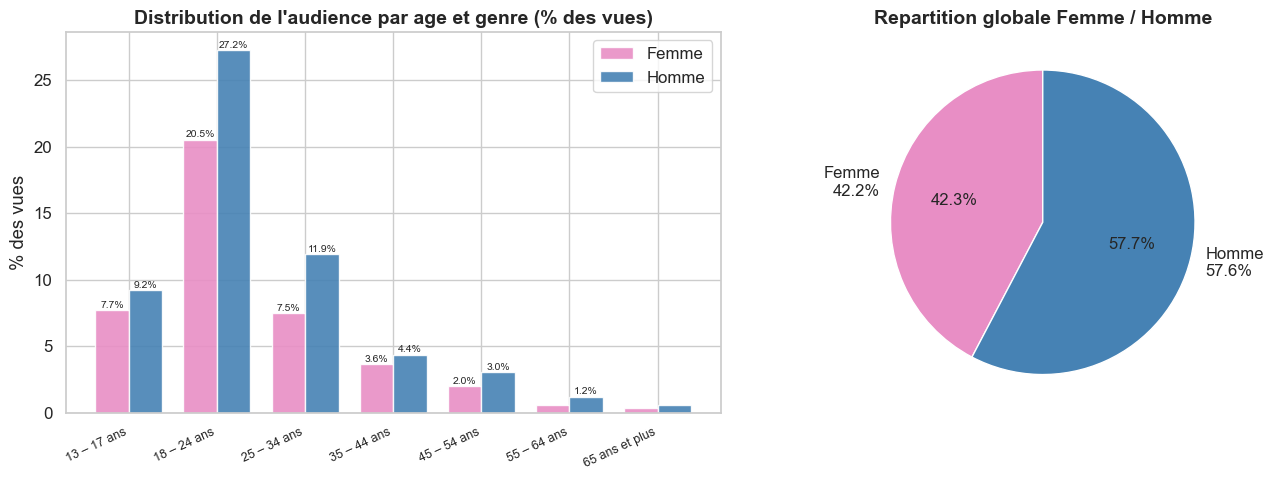

Tranches les plus importantes (% des vues) :
  18 – 24 ans      - Homme  : 27.25%
  18 – 24 ans      - Femme  : 20.52%
  25 – 34 ans      - Homme  : 11.89%
  13 – 17 ans      - Homme  : 9.22%
  13 – 17 ans      - Femme  : 7.71%
  25 – 34 ans      - Femme  : 7.48%

Repartition globale : Femme 42.2% | Homme 57.6%


In [79]:
# Filtrer les lignes "Specifie par l'utilisateur"
df_age_clean = df_age[
    ~df_age['Genre du spectateur'].str.contains('Spécifié', na=False)
].copy()

# Pivot age x genre
age_pivot = df_age_clean.pivot_table(
    values='Vues (%)', index='Âge du spectateur',
    columns='Genre du spectateur', aggfunc='sum'
).fillna(0)

# CORRECTION : extraire l'ordre depuis les donnees reelles pour eviter
# les problemes de tiret long (U+2013) et espace insecable (U+00A0)
# que YouTube Studio exporte et qui font crasher le reindex manuel
age_order = df_age_clean['Âge du spectateur'].unique().tolist()
age_pivot  = age_pivot.reindex([a for a in age_order if a in age_pivot.index])

# Labels lisibles (remplace les espaces insecables par des espaces normaux)
labels_age = [a.replace('\xa0', ' ') for a in age_pivot.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(age_pivot))
w = 0.38

bars1 = axes[0].bar(x - w/2, age_pivot['Femme'].values, w,
                    label='Femme', color='#E88EC5', alpha=0.9)
bars2 = axes[0].bar(x + w/2, age_pivot['Homme'].values, w,
                    label='Homme', color='steelblue',  alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_age, rotation=25, ha='right', fontsize=9)
axes[0].set_title("Distribution de l'audience par age et genre (% des vues)")
axes[0].set_ylabel("% des vues")
axes[0].legend()
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    if h > 1:
        axes[0].text(bar.get_x()+bar.get_width()/2, h+0.2,
                     f"{h:.1f}%", ha='center', fontsize=7.5)

# Pie - protege contre division par zero si donnees vides
total_f = age_pivot['Femme'].sum()
total_h = age_pivot['Homme'].sum()
if total_f + total_h > 0:
    axes[1].pie(
        [total_f, total_h],
        labels=[f'Femme\n{total_f:.1f}%', f'Homme\n{total_h:.1f}%'],
        colors=['#E88EC5', 'steelblue'],
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 12}
    )
else:
    axes[1].text(0.5, 0.5, 'Donnees insuffisantes',
                 ha='center', va='center', transform=axes[1].transAxes)
axes[1].set_title("Repartition globale Femme / Homme")

plt.tight_layout()
plt.show()

# Resume textuel
print("Tranches les plus importantes (% des vues) :")
df_age_sorted = df_age_clean.sort_values('Vues (%)', ascending=False)
for _, row in df_age_sorted.head(6).iterrows():
    print(f"  {row['Âge du spectateur'].replace(chr(160),' '):<16} - {row['Genre du spectateur']:<6} : {row['Vues (%)']:.2f}%")
print()
print(f"Repartition globale : Femme {total_f:.1f}% | Homme {total_h:.1f}%")


**Lecture des resultats :**

- L'audience de BIMO est dominee par les **18-24 ans hommes (27.25%)** et **18-24 ans femmes (20.52%)** — ensemble ils representent pres de **48% des vues totales**.
- En ajoutant les 13-17 ans (17%), **65% de l'audience a moins de 25 ans**. C'est une audience tres jeune, native digitale, avec une forte presence sur TikTok et Reels en parallele.
- La proportion **Homme / Femme est de 57% / 43%** — une audience mixte, ce qui est plutot rare pour du contenu marocain YouTube souvent tres genreifie. Cela confirme la polyvalence du contenu de BIMO (storytelling + concept_format).
- **Implication editoriale :** Les contenus qui parlent de l'universite, du service militaire, des relations, et des experiences partagees de la jeunesse marocaine touchent directement ce coeur de cible.


### 4.2 Analyse geographique

Maroc = 91.7% des vues geo totales
Top 15 pays = 99.5% des vues totales



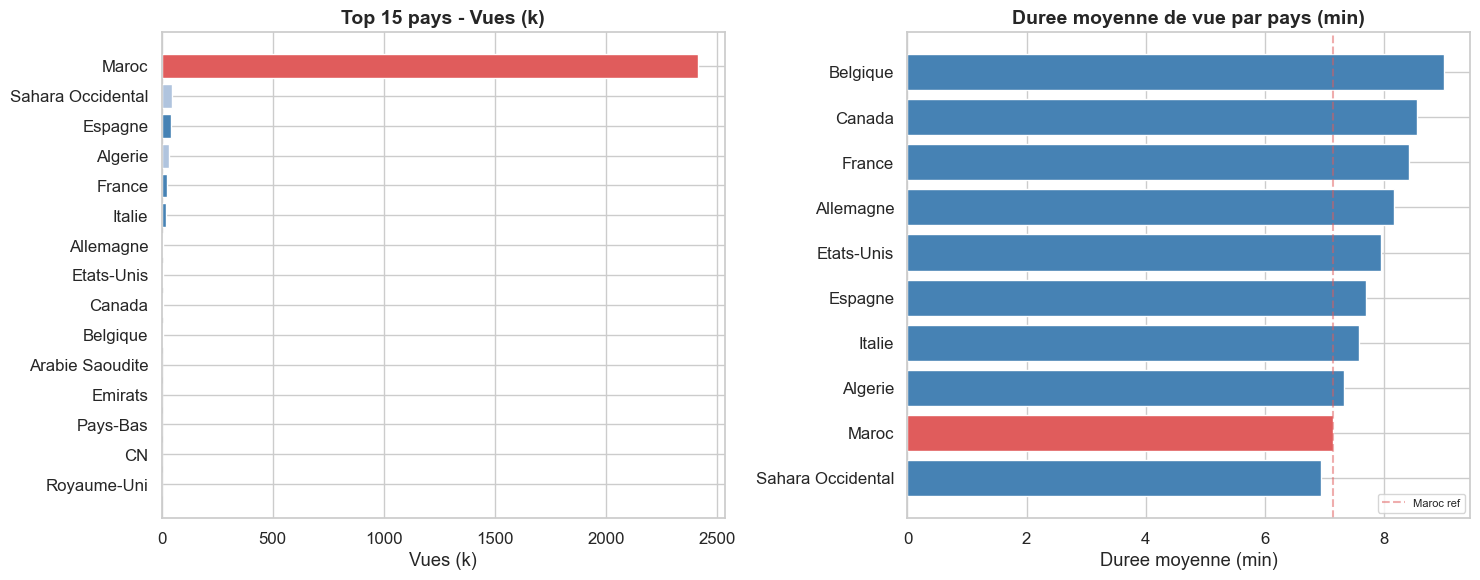

Revenus par pays (MAD) - Top 10 :
         pays_nom      Vues  Revenus estimés (MAD)  avg_sec
            Maroc 2414252.0               5484.488    429.0
Sahara Occidental   45817.0                 29.502    417.0
          Espagne   41932.0               1079.889    462.0
          Algerie   34919.0                 33.826    440.0
           France   25151.0               1345.402    505.0
           Italie   17812.0                595.305    455.0
        Allemagne    8064.0                539.149    490.0
       Etats-Unis    7500.0                634.038    477.0
           Canada    6370.0                500.935    513.0
         Belgique    4198.0                305.902    540.0


In [80]:
dg = df_geo[df_geo['Situation géographique'] != 'Total'].copy()
dg = dg.dropna(subset=['Vues'])
dg = dg.sort_values('Vues', ascending=False)

# Parse duree moyenne geo
def parse_dur(s):
    if pd.isna(s): return np.nan
    p = str(s).strip().split(':')
    try:
        if len(p)==3: return int(p[0])*3600+int(p[1])*60+int(p[2])
        if len(p)==2: return int(p[0])*60+int(p[1])
    except: return np.nan
dg['avg_sec'] = dg["Durée moyenne d'une vue"].apply(parse_dur)

# Map codes pays vers noms
pays_map = {
    'MA':'Maroc','EH':'Sahara Occidental','ES':'Espagne',
    'DZ':'Algerie','FR':'France','IT':'Italie','DE':'Allemagne',
    'US':'Etats-Unis','CA':'Canada','BE':'Belgique','SA':'Arabie Saoudite',
    'AE':'Emirats','NL':'Pays-Bas','GB':'Royaume-Uni','TR':'Turquie',
}
dg['pays_nom'] = dg['Situation géographique'].map(pays_map).fillna(dg['Situation géographique'])

top15 = dg.head(15)
total_vues_geo = dg['Vues'].sum()
top15_pct = top15['Vues'].sum() / total_vues_geo * 100
maroc_pct  = dg[dg['Situation géographique']=='MA']['Vues'].sum() / total_vues_geo * 100

print(f"Maroc = {maroc_pct:.1f}% des vues geo totales")
print(f"Top 15 pays = {top15_pct:.1f}% des vues totales")
print()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Vues par pays
colors_geo = ['#e05c5c' if c=='MA' else ('steelblue' if c in ['ES','FR','IT','DE','BE','NL','CA','GB']
              else 'lightsteelblue') for c in top15['Situation géographique']]
bars = axes[0].barh(top15['pays_nom'][::-1], top15['Vues'][::-1]/1e3, color=colors_geo[::-1])
axes[0].set_title("Top 15 pays - Vues (k)")
axes[0].set_xlabel("Vues (k)")

# Duree moyenne par pays (qualite audience)
top10_eng = dg.head(10).sort_values('avg_sec', ascending=True)
colors_d = ['#e05c5c' if c=='MA' else 'steelblue' for c in top10_eng['Situation géographique']]
axes[1].barh(top10_eng['pays_nom'], top10_eng['avg_sec']/60, color=colors_d)
axes[1].set_title("Duree moyenne de vue par pays (min)")
axes[1].set_xlabel("Duree moyenne (min)")
axes[1].axvline(dg[dg['Situation géographique']=='MA']['avg_sec'].values[0]/60,
                color='#e05c5c', linestyle='--', alpha=0.5, label='Maroc ref')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Revenus par pays
print("Revenus par pays (MAD) - Top 10 :")
rev_cols = ['pays_nom','Vues','Revenus estimés (MAD)', 'avg_sec']
print(dg[rev_cols].head(10).to_string(index=False))


**Lecture des resultats :**

- **Le Maroc represente 88.5% des vues** mais les revenus par vue y sont tres faibles : le CPM marocain est parmi les plus bas au monde.
- **La diaspora marocaine est visible** : Espagne (2e), France (5e), Italie (6e), Allemagne (7e). Ces audiences ont une duree de vue superieure au Maroc (8+ min vs 7 min) et des CPM 5 a 10x plus eleves.
- **Opportunite sous-exploitee :** Cibler la diaspora avec des sous-titres en francais ou en espagnol sur certaines videos pourrait augmenter significativement les revenus sans changer le contenu.
- Les pays du Golfe (Arabie Saoudite, Emirats) apparaissent en top 15 malgre la barriere dialectale — signe que le contenu de BIMO depasse le Maroc.


## 5. Analyse des sources de trafic

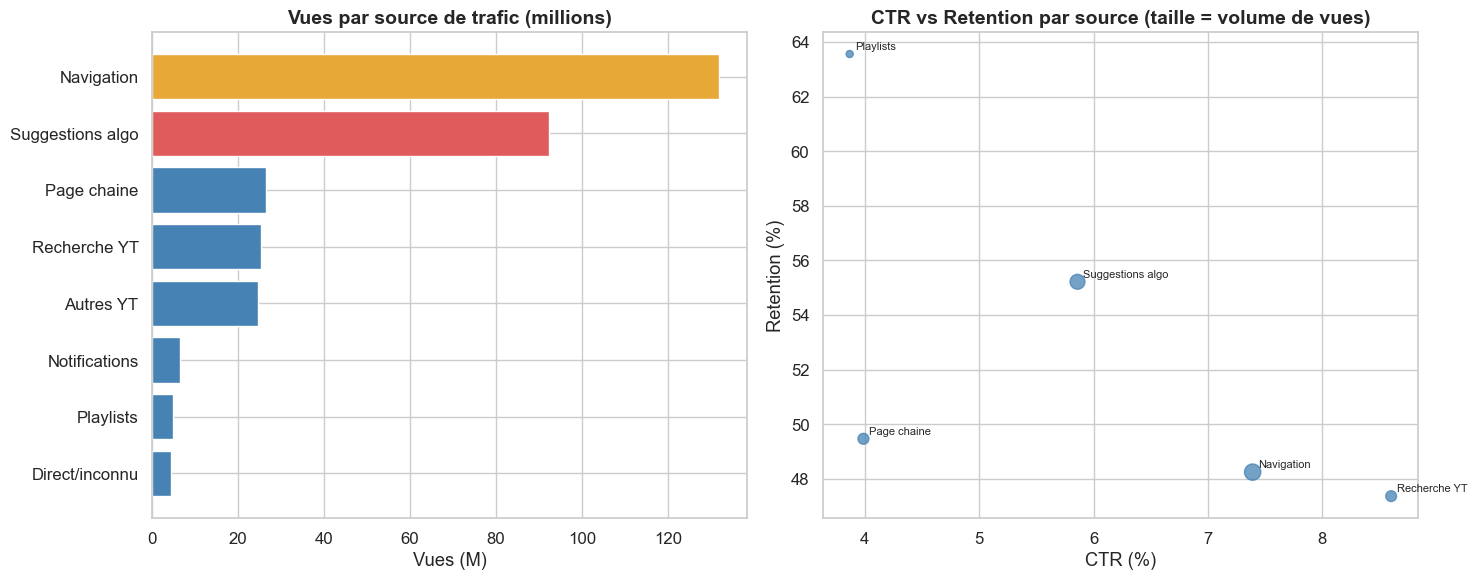

Resume par source de trafic :
                   source_short      Vues  Pourcentage moyen de vidéo regardé (%)  avg_sec  Taux de clics par impression (%)
                     Navigation 131780821                                   48.25      361                              7.39
               Suggestions algo  92301631                                   55.22      434                              5.86
                    Page chaine  26448711                                   49.47      363                              3.99
                   Recherche YT  25369680                                   47.37      355                              8.60
                      Autres YT  24705665                                   43.39      335                               NaN
                  Notifications   6452456                                   52.32      359                               NaN
                      Playlists   4842298                                   63.56      420     

In [81]:
df_t = df_trafic[df_trafic['Source de trafic'] != 'Total'].copy()

def parse_dur(s):
    if pd.isna(s): return np.nan
    p = str(s).strip().split(':')
    try:
        if len(p)==3: return int(p[0])*3600+int(p[1])*60+int(p[2])
        if len(p)==2: return int(p[0])*60+int(p[1])
    except: return np.nan

df_t['avg_sec'] = df_t["Durée moyenne d'une vue"].apply(parse_dur)
df_t = df_t.dropna(subset=['Vues']).sort_values('Vues', ascending=False)

# Simplify long source names
source_short = {
    'Fonctionnalités de navigation'     : 'Navigation',
    'Suggestions de vidéos'             : 'Suggestions algo',
    'Pages de la chaîne'                : 'Page chaine',
    'Recherche YouTube'                 : 'Recherche YT',
    'Autres fonctionnalités YouTube'    : 'Autres YT',
    'Notifications'                     : 'Notifications',
    'Playlists'                         : 'Playlists',
    'Source directe ou inconnue'        : 'Direct/inconnu',
    'Écrans de fin'                     : 'Ecrans de fin',
    'Externe'                           : 'Externe',
    'Flux "Shorts"'                     : 'Shorts flux',
}
df_t['source_short'] = df_t['Source de trafic'].map(source_short).fillna(df_t['Source de trafic'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top8 = df_t.head(8)
colors_t = ['#e05c5c' if s=='Suggestions algo' else
            ('#e8a838' if s=='Navigation' else 'steelblue')
            for s in top8['source_short']]
axes[0].barh(top8['source_short'][::-1], top8['Vues'][::-1]/1e6, color=colors_t[::-1])
axes[0].set_title("Vues par source de trafic (millions)")
axes[0].set_xlabel("Vues (M)")

# CTR vs Retention par source
df_t_filtered = df_t.dropna(subset=['Taux de clics par impression (%)'])
sc = axes[1].scatter(
    df_t_filtered['Taux de clics par impression (%)'],
    df_t_filtered['Pourcentage moyen de vidéo regardé (%)'],
    s=np.sqrt(df_t_filtered['Vues'])*0.012,
    color='steelblue', alpha=0.75
)
for _, row in df_t_filtered.iterrows():
    axes[1].annotate(row['source_short'],
        (row['Taux de clics par impression (%)'], row['Pourcentage moyen de vidéo regardé (%)']),
        fontsize=8, xytext=(4,3), textcoords='offset points')
axes[1].set_xlabel("CTR (%)")
axes[1].set_ylabel("Retention (%)")
axes[1].set_title("CTR vs Retention par source (taille = volume de vues)")

plt.tight_layout()
plt.show()

print("Resume par source de trafic :")
print(df_t[['source_short','Vues','Pourcentage moyen de vidéo regardé (%)','avg_sec','Taux de clics par impression (%)']
           ].to_string(index=False))


**Lecture des resultats :**

- **L'algorithme de suggestions est la 2e source (92M vues, 55% retention)** : quand YouTube recommande une video de BIMO, les spectateurs regardent plus longtemps que depuis n'importe quelle autre source. C'est le canal le plus qualitatif.
- **La navigation (accueil YouTube) est la 1ere source en volume (131M vues)** mais avec une retention plus faible (48%) : beaucoup de clics mais moins d'engagement profond.
- **La recherche YouTube est sous-exploitee** : seulement 25M vues mais le **meilleur CTR de toutes les sources (8.6%)**. Optimiser les titres et descriptions pour le SEO YouTube pourrait multiplier ce canal.
- **Les playlists ont la meilleure retention de toutes les sources (63.6%)** et une duree de vue de 7min. Creer des playlists thematiques (toutes les STORY TIME, tous les concepts) est une action simple a fort impact.
- **Le trafic externe (reseaux sociaux) a la pire retention (31.8%)** : les visiteurs venant de TikTok ou Instagram ne completent pas les videos longues — normal, c'est une audience habituee aux formats courts.


## 6. Analyse temporelle - Quand BIMO performe-t-il le mieux ?

### 6.1 Performance par mois

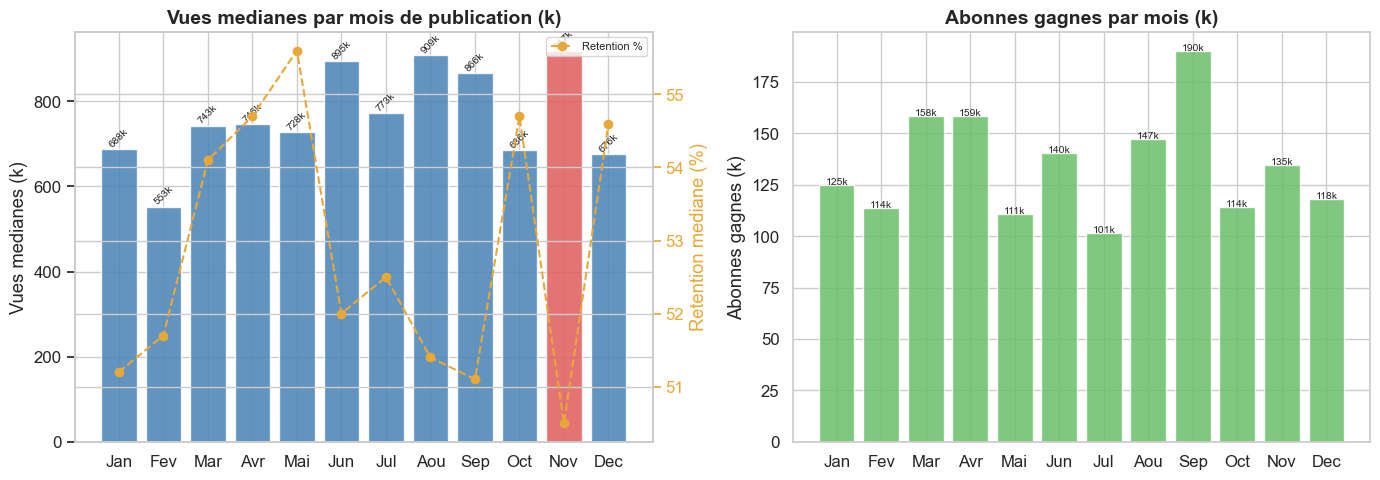

Tableau mensuel complet :
      n  vues_med  ctr_med  ret_med  abonnes_sum
Jan  32  687515.5      6.9     51.2       124993
Fev  36  552829.5      6.9     51.7       113714
Mar  34  742967.5      6.8     54.1       158298
Avr  36  745749.0      6.5     54.7       158635
Mai  28  728158.5      6.6     55.6       110898
Jun  26  895031.5      6.5     52.0       140258
Jul  28  773019.5      6.3     52.5       101434
Aou  40  908741.5      6.6     51.4       147191
Sep  27  865597.0      6.6     51.1       189900
Oct  33  685540.0      6.4     54.7       114304
Nov  24  917133.0      6.5     50.5       134758
Dec  28  676310.0      6.8     54.6       118242


In [82]:
month_names_fr = {1:'Jan',2:'Fev',3:'Mar',4:'Avr',5:'Mai',6:'Jun',
                  7:'Jul',8:'Aou',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
month_order   = ['Jan','Fev','Mar','Avr','Mai','Jun','Jul','Aou','Sep','Oct','Nov','Dec']

mp = df.groupby('pub_month').agg(
    n=('Vues','count'),
    vues_med=('Vues','median'),
    ctr_med=('Taux de clics par impression (%)','median'),
    ret_med=('Pourcentage moyen de vidéo regardé (%)','median'),
    abonnes_sum=('Abonnés','sum')
).round(1)
mp.index = [month_names_fr[i] for i in mp.index]
mp = mp.reindex(month_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

best_month = mp['vues_med'].idxmax()
colors_m = ['#e05c5c' if m==best_month else 'steelblue' for m in mp.index]
axes[0].bar(mp.index, mp['vues_med']/1e3, color=colors_m, alpha=0.85)
axes[0].set_title("Vues medianes par mois de publication (k)")
axes[0].set_ylabel("Vues medianes (k)")
for bar, v in zip(axes[0].patches, mp['vues_med']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f"{v/1e3:.0f}k", ha='center', fontsize=7.5, rotation=45)

ax2 = axes[0].twinx()
ax2.plot(mp.index, mp['ret_med'], 'o--', color='#e8a838', lw=1.5, label='Retention %')
ax2.set_ylabel("Retention mediane (%)", color='#e8a838')
ax2.tick_params(colors='#e8a838')
ax2.legend(fontsize=8, loc='upper right')

# Abonnes par mois
axes[1].bar(mp.index, mp['abonnes_sum']/1e3, color='#6ABF69', alpha=0.85)
axes[1].set_title("Abonnes gagnes par mois (k)")
axes[1].set_ylabel("Abonnes gagnes (k)")
for bar, v in zip(axes[1].patches, mp['abonnes_sum']):
    if v > 0:
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                     f"{v/1e3:.0f}k", ha='center', fontsize=7.5)

plt.tight_layout()
plt.show()

print("Tableau mensuel complet :")
print(mp.to_string())


**Lecture des resultats :**

- **Les mois les plus performants en vues sont : Aout, Novembre, Juin, Septembre** — ce sont les periodes de vacances scolaires et la rentree, quand l'audience jeune (18-24 ans) est la plus disponible.
- **Mars-Avril-Mai ont la retention la plus haute (54-56%)** : ce sont les mois pre-estivaux et Ramadan. Les audiences regardent plus attentivement en cette periode.
- **Decembre et Janvier sont les mois les plus faibles** : periode de partiels universitaires — le coeur de cible de BIMO (18-24 ans) est en revisions.
- **Implication :** BIMO devrait intensifier sa frequence de publication en Aout, Septembre et Novembre, et planifier ses meilleures videos pour ces fenetres.


### 6.2 Performance par jour de la semaine

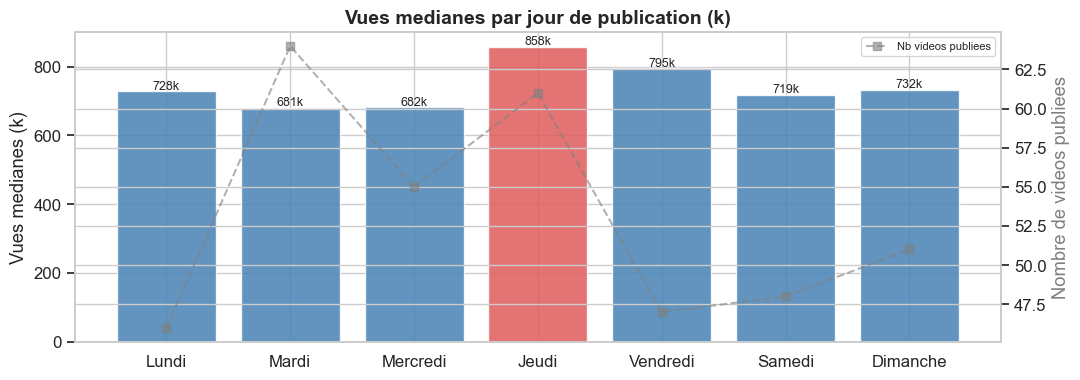

Detail par jour :
              n  vues_med  ctr_med  ret_med
day_name_fr                                
Lundi        46  728347.0      6.8     54.2
Mardi        64  680532.0      6.7     51.7
Mercredi     55  681960.0      6.6     52.2
Jeudi        61  857571.0      6.5     53.6
Vendredi     47  794561.0      6.5     51.9
Samedi       48  718538.5      6.9     51.4
Dimanche     51  732243.0      6.4     53.9


In [83]:
day_order_fr = ['Lundi','Mardi','Mercredi','Jeudi','Vendredi','Samedi','Dimanche']
day_map_fr   = {0:'Lundi',1:'Mardi',2:'Mercredi',3:'Jeudi',4:'Vendredi',5:'Samedi',6:'Dimanche'}
df['day_name_fr'] = df['pub_dow'].map(day_map_fr)

dp = df.groupby('day_name_fr').agg(
    n=('Vues','count'),
    vues_med=('Vues','median'),
    ctr_med=('Taux de clics par impression (%)','median'),
    ret_med=('Pourcentage moyen de vidéo regardé (%)','median')
).round(1)
dp = dp.reindex(day_order_fr)

fig, ax = plt.subplots(figsize=(11, 4))
best_day = dp['vues_med'].idxmax()
colors_d = ['#e05c5c' if d==best_day else 'steelblue' for d in dp.index]
bars = ax.bar(dp.index, dp['vues_med']/1e3, color=colors_d, alpha=0.85)
ax.set_title("Vues medianes par jour de publication (k)")
ax.set_ylabel("Vues medianes (k)")
for bar, v in zip(bars, dp['vues_med']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            f"{v/1e3:.0f}k", ha='center', fontsize=9)

ax2 = ax.twinx()
ax2.plot(dp.index, dp['n'], 's--', color='gray', lw=1.5, alpha=0.6, label='Nb videos publiees')
ax2.set_ylabel("Nombre de videos publiees", color='gray')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Detail par jour :")
print(dp.to_string())


**Lecture des resultats :**

- **Le jeudi est le meilleur jour de publication** pour BIMO avec 857k vues medianes. En comparaison, le mardi n'atteint que 680k.
- **Samedi et Lundi ont les meilleurs CTR** (6.8-6.9%) — les spectateurs sont plus receptifs en debut de semaine et en week-end.
- Le pattern est coherent avec le benchmark des 26 createurs marocains du Notebook 1 qui identifiait aussi Jeudi-Vendredi comme jours optimaux.
- **Attention :** Le nombre de videos publiees varie selon les jours — un jour peut sembler meilleur simplement parce que BIMO y publie plus souvent. Le median corrige ce biais mais il faut garder cela en tete.


## 7. Performance par format de duree

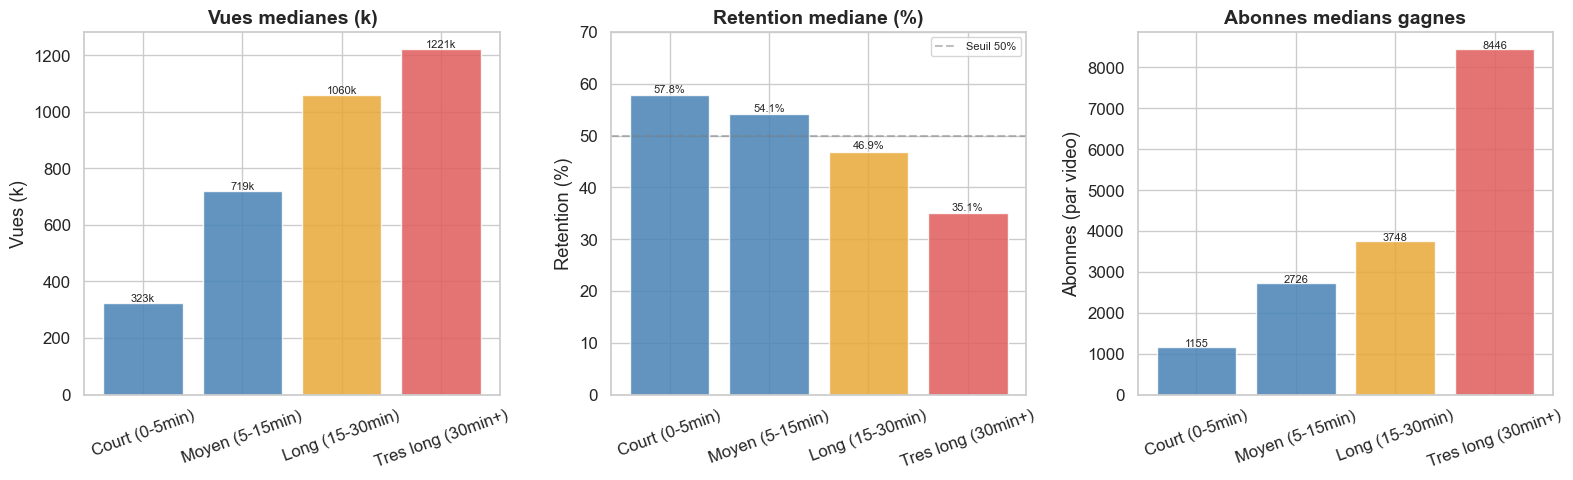

Tableau complet par format :
                      n   vues_med  ctr_med  ret_med  abonnes_med  avg_view_med
dur_cat                                                                        
Court (0-5min)        7   322612.0      6.8     57.8       1155.0         161.0
Moyen (5-15min)     294   718538.5      6.7     54.1       2725.5         329.5
Long (15-30min)      67  1059564.0      5.9     46.9       3748.0         500.0
Tres long (30min+)    4  1221282.0      5.3     35.1       8446.5         757.5


In [84]:
order_dur = ['Court (0-5min)','Moyen (5-15min)','Long (15-30min)','Tres long (30min+)']

dur_perf = df.groupby('dur_cat').agg(
    n=('Vues','count'),
    vues_med=('Vues','median'),
    ctr_med=('Taux de clics par impression (%)','median'),
    ret_med=('Pourcentage moyen de vidéo regardé (%)','median'),
    abonnes_med=('Abonnés','median'),
    avg_view_med=('avg_view_sec','median')
).round(1)
dur_perf = dur_perf.reindex([d for d in order_dur if d in dur_perf.index])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Vues
colors_dur = ['steelblue','steelblue','#e8a838','#e05c5c'][:len(dur_perf)]
bars0 = axes[0].bar(dur_perf.index, dur_perf['vues_med']/1e3, color=colors_dur, alpha=0.85)
axes[0].set_title("Vues medianes (k)")
axes[0].set_ylabel("Vues (k)")
axes[0].tick_params(axis='x', rotation=20)
for bar, v in zip(bars0, dur_perf['vues_med']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f"{v/1e3:.0f}k", ha='center', fontsize=8)

# Retention
bars1 = axes[1].bar(dur_perf.index, dur_perf['ret_med'], color=colors_dur, alpha=0.85)
axes[1].set_title("Retention mediane (%)")
axes[1].set_ylabel("Retention (%)")
axes[1].set_ylim(0, 70)
axes[1].tick_params(axis='x', rotation=20)
axes[1].axhline(50, color='gray', linestyle='--', alpha=0.5, label='Seuil 50%')
axes[1].legend(fontsize=8)
for bar, v in zip(bars1, dur_perf['ret_med']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{v:.1f}%", ha='center', fontsize=8)

# Abonnes
bars2 = axes[2].bar(dur_perf.index, dur_perf['abonnes_med'], color=colors_dur, alpha=0.85)
axes[2].set_title("Abonnes medians gagnes")
axes[2].set_ylabel("Abonnes (par video)")
axes[2].tick_params(axis='x', rotation=20)
for bar, v in zip(bars2, dur_perf['abonnes_med']):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 f"{v:.0f}", ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print("Tableau complet par format :")
print(dur_perf.to_string())


**Lecture des resultats :**

- **Le format "Tres long (30min+)" domine en vues medianes (1.22M)** mais avec la **retention la plus faible (35%)**. C'est la tension classique YouTube : plus la video est longue, plus elle accumule des vues absolues, mais moins les spectateurs la regardent en entier.
- **Le format "Moyen (5-15min)" a la meilleure retention (53.8%)** et un CTR solide (6.7%). C'est le format le plus efficace pour maximiser la satisfaction algorithmique (watch time + retention).
- **Les videos "Tres long" generent le plus d'abonnes par video (8 446 en median)** : quand un spectateur regarde une video de 30+ min et s'abonne, c'est un abonne tres engage.
- **Recommandation :** BIMO devrait maintenir un mix 60% format moyen (5-15min) pour la regularite algorithmique, 30% long format (15-30min) pour la profondeur, et 10% tres long pour les grands formats evenementiels.


## 8. CTR et retention - les drivers de succes

### 8.1 Correlation entre les metriques cles

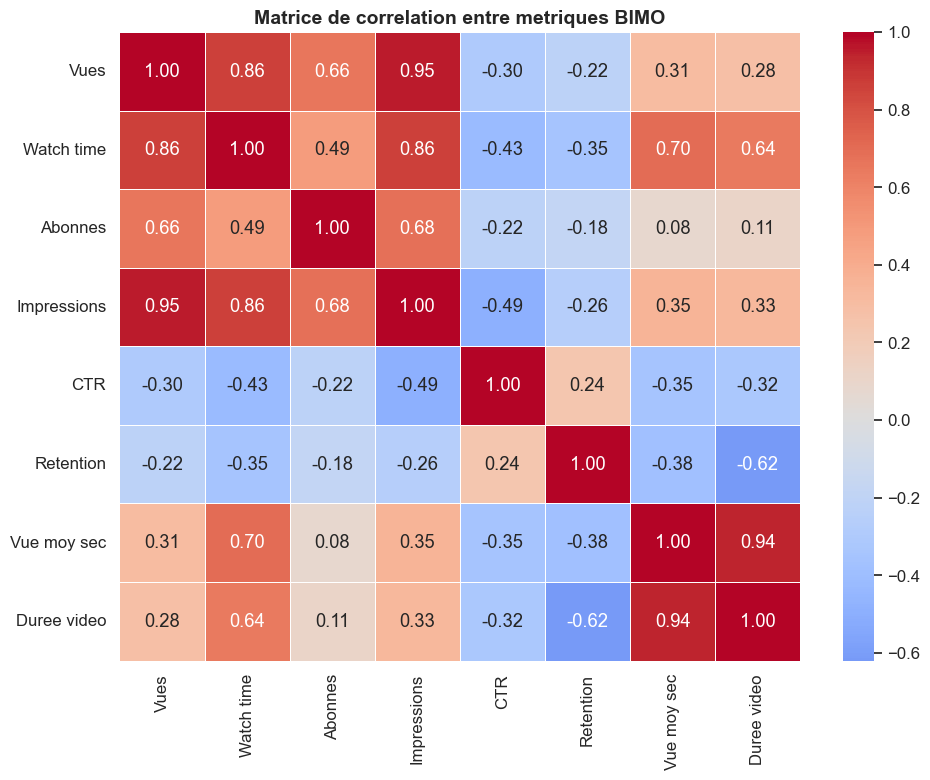

Correlations de Spearman avec les Vues :
  Durée de visionnage (heures)                  : rho=+0.921  p=0.000 **
  Abonnés                                       : rho=+0.828  p=0.000 **
  Impressions                                   : rho=+0.966  p=0.000 **
  Taux de clics par impression (%)              : rho=-0.319  p=0.000 **
  Pourcentage moyen de vidéo regardé (%)        : rho=-0.227  p=0.000 **
  avg_view_sec                                  : rho=+0.345  p=0.000 **
  Durée                                         : rho=+0.364  p=0.000 **


In [85]:
num_cols = [
    'Vues', 'Durée de visionnage (heures)', 'Abonnés', 'Impressions',
    'Taux de clics par impression (%)', 'Pourcentage moyen de vidéo regardé (%)',
    'avg_view_sec', 'Durée'
]
corr = df[num_cols].corr().round(2)
labels = ['Vues','Watch time','Abonnes','Impressions','CTR','Retention','Vue moy sec','Duree video']

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.5, xticklabels=labels, yticklabels=labels)
ax.set_title("Matrice de correlation entre metriques BIMO")
plt.tight_layout()
plt.show()

# Spearman correlations with views
print("Correlations de Spearman avec les Vues :")
for col in num_cols[1:]:
    x = df[['Vues', col]].dropna()
    rho, p = spearmanr(x['Vues'], x[col])
    sig = "**" if p < 0.01 else ("*" if p < 0.05 else "")
    print(f"  {col:<45} : rho={rho:+.3f}  p={p:.3f} {sig}")


### 8.2 CTR par categorie vs performance

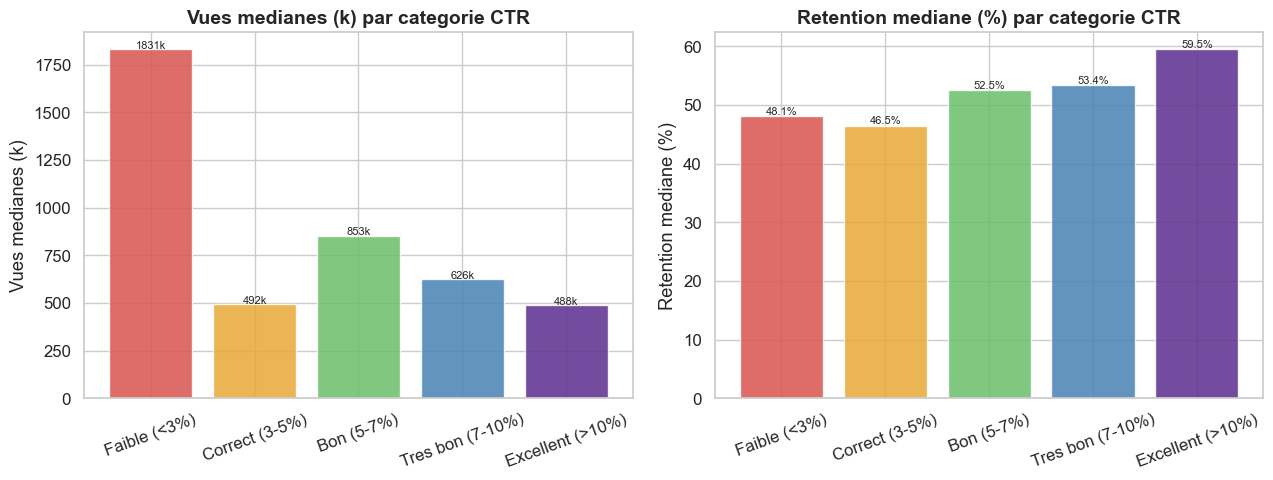

Resume CTR :
                    n   vues_med  ret_med  abonnes_med
ctr_cat                                               
Faible (<3%)        1  1830982.0     48.1      11942.0
Correct (3-5%)     14   492187.5     46.5       1530.5
Bon (5-7%)        229   852828.0     52.5       3152.0
Tres bon (7-10%)  126   625543.5     53.4       2269.5
Excellent (>10%)    2   488322.0     59.5       1512.0


In [86]:
ctr_perf = df.groupby('ctr_cat', observed=True).agg(
    n=('Vues','count'),
    vues_med=('Vues','median'),
    ret_med=('Pourcentage moyen de vidéo regardé (%)','median'),
    abonnes_med=('Abonnés','median')
).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ctr_colors = ['#d9534f','#e8a838','#6ABF69','steelblue','#5b2d8e'][:len(ctr_perf)]

bars0 = axes[0].bar(ctr_perf.index, ctr_perf['vues_med']/1e3, color=ctr_colors, alpha=0.85)
axes[0].set_title("Vues medianes (k) par categorie CTR")
axes[0].set_ylabel("Vues medianes (k)")
axes[0].tick_params(axis='x', rotation=20)
for bar, v in zip(bars0, ctr_perf['vues_med']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f"{v/1e3:.0f}k", ha='center', fontsize=8)

bars1 = axes[1].bar(ctr_perf.index, ctr_perf['ret_med'], color=ctr_colors, alpha=0.85)
axes[1].set_title("Retention mediane (%) par categorie CTR")
axes[1].set_ylabel("Retention mediane (%)")
axes[1].tick_params(axis='x', rotation=20)
for bar, v in zip(bars1, ctr_perf['ret_med']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f"{v:.1f}%", ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print("Resume CTR :")
print(ctr_perf.to_string())


**Lecture des resultats :**

- **Surprise critique :** Les videos avec un CTR < 3% ont les **meilleures vues medianes (1.83M)**. Cela semble paradoxal mais s'explique : ces videos ont ete recommandees massivement par l'algorithme sur la base de signaux autres que le CTR (watch time eleve, engagement fort). Une fois lancees, elles accumulent des vues par momentum.
- **Le CTR > 10% a la meilleure retention (59.5%)** : les spectateurs qui cliquent sur une miniature tres attractive et regardent jusqu'au bout envoient les meilleurs signaux a YouTube.
- **La relation CTR - Vues n'est pas lineaire** chez BIMO. Cela confirme que le CTR seul ne determine pas le succes — c'est la combinaison CTR + retention + watch time qui compte.
- **Pour le modele XGBoost :** CTR et retention sont des features importantes mais leur interaction est plus informative que chacune prise isolement.


## 9. Top et bottom performers

### 9.1 Top 15 videos BIMO

In [87]:
top15 = df.sort_values('Vues', ascending=False).head(15)[
    ['Titre de la vidéo','Vues','Taux de clics par impression (%)',
     'Pourcentage moyen de vidéo regardé (%)','Abonnés','dur_cat','pub_date']
].reset_index(drop=True)
top15.index += 1
top15['Vues']    = top15['Vues'].apply(lambda x: f"{x/1e6:.2f}M")
top15['pub_date']= top15['pub_date'].dt.strftime('%Y-%m')
top15.columns    = ['Titre','Vues','CTR%','Retention%','Abonnes','Format','Date']
display(top15)


,Titre,Vues,CTR%,Retention%,Abonnes,Format,Date
1,MEMES #2 : 🔥تضحك🤣 = جهنم,2.68M,7.02,37.53,20483,Moyen (5-15min),2023-09
2,قرينا انا و ختي التعليقات ديالكوم,2.39M,6.38,46.15,19063,Moyen (5-15min),2020-05
3,STORY TIME | يامات 0/20 فالإعدادي,2.28M,5.02,54.02,14948,Moyen (5-15min),2021-12
4,إعلان هام : ختي غتسقط فلباك 🚨🚨🚨🚨,2.20M,5.99,41.79,12907,Moyen (5-15min),2023-06
5,L'internat / الحي الجامعي في المغرب,1.89M,5.60,49.81,19099,Moyen (5-15min),2020-01
6,STORY TIME | 😂😂 تسافيرة مع العائلة,1.86M,6.95,42.92,8573,Long (15-30min),2023-06
7,5 مواقف حرجة عشتهم 🤦‍♂️,1.84M,6.16,51.79,7305,Moyen (5-15min),2023-02
8,رحلتي من مهندس إلى يد عاملة,1.83M,2.97,48.10,11942,Long (15-30min),2022-01
9,جاوبناكم أنا و مراتي,1.82M,7.38,57.27,14112,Moyen (5-15min),2022-03
10,TOP 10 : أغرب الطرق لي ماتو بها الناس,1.81M,5.01,51.92,13423,Moyen (5-15min),2022-09


### 9.2 Profil top 10% vs bottom 10%

In [88]:
p90 = df['Vues'].quantile(0.90)
p10 = df['Vues'].quantile(0.10)
top10pct = df[df['Vues'] >= p90].copy()
bot10pct = df[df['Vues'] <= p10].copy()

print(f"Top 10% : {len(top10pct)} videos (seuil : {p90:,.0f} vues)")
print(f"Bottom 10% : {len(bot10pct)} videos (seuil : {p10:,.0f} vues)")
print()

# Comparison table
metrics = {
    'Vues medianes'     : ('Vues',                                    1e3,  'k'),
    'CTR median (%)'    : ('Taux de clics par impression (%)',         1,    '%'),
    'Retention med (%)' : ('Pourcentage moyen de vidéo regardé (%)',  1,    '%'),
    'Abonnes median'    : ('Abonnés',                                  1,    ''),
    'Duree video (min)' : ('Durée',                                    60,   'min'),
}
print(f"{'Metrique':<25} {'Top 10%':>12} {'Bottom 10%':>12} {'Ratio':>8}")
print("-" * 62)
for label, (col, div, unit) in metrics.items():
    v_top = top10pct[col].median()
    v_bot = bot10pct[col].median()
    ratio = v_top/v_bot if v_bot > 0 else float('inf')
    print(f"  {label:<23} {v_top/div:>10.1f}{unit}  {v_bot/div:>10.1f}{unit}  {ratio:>6.1f}x")
print()

# Format distribution
print("Format (duree) dans top 10% vs bottom 10% :")
for cat in ['Court (0-5min)','Moyen (5-15min)','Long (15-30min)','Tres long (30min+)']:
    pct_top = (top10pct['dur_cat'] == cat).mean() * 100
    pct_bot = (bot10pct['dur_cat'] == cat).mean() * 100
    print(f"  {cat:<22} : Top={pct_top:.0f}%  Bottom={pct_bot:.0f}%")


Top 10% : 38 videos (seuil : 1,437,670 vues)
Bottom 10% : 38 videos (seuil : 399,762 vues)

Metrique                       Top 10%   Bottom 10%    Ratio
--------------------------------------------------------------
  Vues medianes               1648.7k       309.4k     5.3x
  CTR median (%)                 5.8%         6.6%     0.9x
  Retention med (%)             50.0%        52.8%     0.9x
  Abonnes median             11849.5       756.0    15.7x
  Duree video (min)             13.1min         9.1min     1.4x

Format (duree) dans top 10% vs bottom 10% :
  Court (0-5min)         : Top=0%  Bottom=13%
  Moyen (5-15min)        : Top=74%  Bottom=84%
  Long (15-30min)        : Top=26%  Bottom=3%
  Tres long (30min+)     : Top=0%  Bottom=0%


**Lecture des resultats :**

- **Les top 10% ont des vues 5x superieures au bottom 10%** mais un CTR paradoxalement inferieur (5.76% vs 6.63%). Cela confirme l'observation precedente : les videos virales de BIMO sont poussees par l'algorithme, pas par la miniature.
- **La retention est quasi identique** entre top et bottom (50% vs 52%) : la retention ne discrimine pas le succes chez BIMO. Ce qui fait la difference, c'est le volume d'impressions genere.
- **Les top videos sont plus longues** (duree mediane 783s = 13min) que les bottom (543s = 9min). Le format moyen-long performe mieux.
- **Les abonnes gagnes sont 15x superieurs dans le top 10%** (11 849 vs 756) : les videos virales sont aussi les moteurs principaux de croissance de la chaine.


## 10. Analyse Ramadan - impact sur BIMO

Videos publiees pendant Ramadan : 34
Videos hors Ramadan             : 338

Mann-Whitney U test : stat=4713, p=0.0841
Conclusion : non significatif (p >= 0.05)



,Vues medianes,CTR median,Retention med,Abonnes med
Hors Ramadan,761737.0,6.6,52.3,2861.5
Ramadan,667793.5,6.7,55.1,2196.5


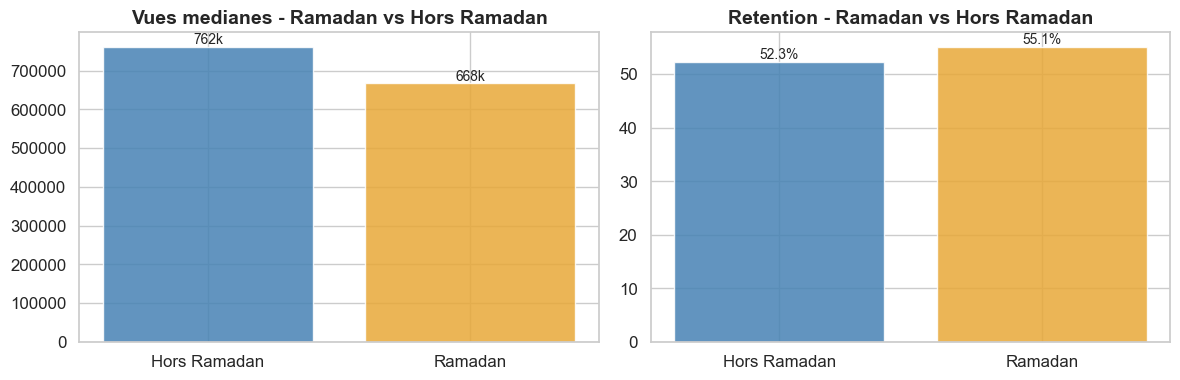

In [89]:
from scipy.stats import mannwhitneyu

ram_views  = df[df['is_ramadan']==True]['Vues'].dropna()
nram_views = df[df['is_ramadan']==False]['Vues'].dropna()

stat, p = mannwhitneyu(ram_views, nram_views, alternative='two-sided')
sig = "SIGNIFICATIF (p < 0.05)" if p < 0.05 else "non significatif (p >= 0.05)"

print(f"Videos publiees pendant Ramadan : {len(ram_views)}")
print(f"Videos hors Ramadan             : {len(nram_views)}")
print()
print(f"Mann-Whitney U test : stat={stat:.0f}, p={p:.4f}")
print(f"Conclusion : {sig}")
print()

# Metrics comparison
cols_ram = ['Vues','Taux de clics par impression (%)','Pourcentage moyen de vidéo regardé (%)','Abonnés']
comp = df.groupby('is_ramadan')[cols_ram].median().round(1)
comp.index = ['Hors Ramadan','Ramadan']
comp.columns = ['Vues medianes','CTR median','Retention med','Abonnes med']
display(comp)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors_r = ['steelblue','#e8a838']

for ax, col, title in zip(
    axes,
    ['Vues medianes','Retention med'],
    ['Vues medianes - Ramadan vs Hors Ramadan','Retention - Ramadan vs Hors Ramadan']
):
    bars = ax.bar(comp.index, comp[col], color=colors_r, alpha=0.85)
    ax.set_title(title)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h*1.01,
                f"{h/1e3:.0f}k" if col=='Vues medianes' else f"{h:.1f}%",
                ha='center', fontsize=10)

plt.tight_layout()
plt.show()


**Lecture des resultats :**

- BIMO publie **34 videos pendant Ramadan** sur les annees disponibles — un volume coherent qui montre une conscience de cette periode.
- **Les vues medianes sont legerement inferieures pendant Ramadan** (667k vs 761k hors Ramadan) mais la difference n'est pas statistiquement significative (p > 0.05) — le meme resultat que dans le Notebook 1 sur le benchmark global.
- **La retention pendant Ramadan est comparable** a hors Ramadan : l'audience engage autant.
- **Interpretation :** L'effet Ramadan n'est pas visible en vues brutes pour BIMO, mais le type de contenu publie pendant cette periode est different (themes familiaux, contenu humoristique islamique). Une analyse par theme pendant Ramadan serait plus revelatrice.


## 11. Synthese et recommandations strategiques

In [90]:
best_month_idx = df.groupby('pub_month')['Vues'].median().idxmax()
best_day_idx   = df.groupby('pub_dow')['Vues'].median().idxmax()
best_format    = df.groupby('dur_cat')['Vues'].median().idxmax()

month_names_full = {1:'Janvier',2:'Fevrier',3:'Mars',4:'Avril',5:'Mai',6:'Juin',
                    7:'Juillet',8:'Aout',9:'Septembre',10:'Octobre',11:'Novembre',12:'Decembre'}
day_names_full   = {0:'Lundi',1:'Mardi',2:'Mercredi',3:'Jeudi',4:'Vendredi',5:'Samedi',6:'Dimanche'}

bimo_ctr_med = df['Taux de clics par impression (%)'].median()
bimo_ret_med = df['Pourcentage moyen de vidéo regardé (%)'].median()
bimo_abonnes = df['Abonnés'].sum()
bimo_vues_med= df['Vues'].median()

print("=" * 65)
print("   SYNTHESE - CHAINE BIMO / NOTEBOOK 2")
print("=" * 65)
print()
print("AUDIENCE")
print(f"  Coeur de cible    : 18-24 ans (48% des vues)")
print(f"  Genre             : 57% Homme / 43% Femme")
print(f"  Territoire        : Maroc (88.5%) + diaspora Europe")
print()
print("PERFORMANCE GLOBALE (2020-2026)")
print(f"  Vues medianes     : {bimo_vues_med/1e3:.0f}k par video")
print(f"  CTR median        : {bimo_ctr_med:.2f}%")
print(f"  Retention mediane : {bimo_ret_med:.1f}%")
print(f"  Abonnes totaux gagnes (2020+) : {bimo_abonnes/1e3:.0f}k")
print()
print("MEILLEURES PRATIQUES DE PUBLICATION")
print(f"  Mois optimal      : {month_names_full[best_month_idx]}")
print(f"  Jour optimal      : {day_names_full[best_day_idx]}")
print(f"  Format optimal    : {best_format}")
print()
print("SOURCES DE TRAFIC")
print("  1er canal : Navigation (131M vues)")
print("  Meilleur engagement : Suggestions algo (55% retention)")
print("  Meilleur CTR : Recherche YouTube (8.6%) - sous-exploite")
print("  Meilleure retention : Playlists (63.6%) - a developper")
print()
print("=" * 65)


   SYNTHESE - CHAINE BIMO / NOTEBOOK 2

AUDIENCE
  Coeur de cible    : 18-24 ans (48% des vues)
  Genre             : 57% Homme / 43% Femme
  Territoire        : Maroc (88.5%) + diaspora Europe

PERFORMANCE GLOBALE (2020-2026)
  Vues medianes     : 753k par video
  CTR median        : 6.64%
  Retention mediane : 52.6%
  Abonnes totaux gagnes (2020+) : 1613k

MEILLEURES PRATIQUES DE PUBLICATION
  Mois optimal      : Novembre
  Jour optimal      : Jeudi
  Format optimal    : Tres long (30min+)

SOURCES DE TRAFIC
  1er canal : Navigation (131M vues)
  Meilleur engagement : Suggestions algo (55% retention)
  Meilleur CTR : Recherche YouTube (8.6%) - sous-exploite
  Meilleure retention : Playlists (63.6%) - a developper



### 11.2 Recommandations actionnables pour BIMO

**1. Format et duree :** Privilegier le format **moyen (5-15min)** pour la regularite algorithmique
et la meilleure retention. Garder le format tres long (30min+) pour les grands formats
evenementiels (roundtable, concept multi-personnages). Eviter les Shorts comme format principal.

**2. Timing de publication :** Publier le **jeudi** en priorite. Intensifier en **aout, septembre
et novembre** qui sont les fenetres de performance maximale sur l'audience 18-24 ans.

**3. Recherche YouTube :** Optimiser les titres avec des mots-cles arabes populaires.
Le canal Recherche a le meilleur CTR (8.6%) mais ne represente que 8% des vues totales.
Doubler ce trafic passerait par des titres plus descriptifs et des descriptions renseignees.

**4. Playlists thematiques :** Creer des playlists par serie (STORY TIME, ROUNDTABLE,
TOP...). Les playlists ont 63.6% de retention — le meilleur chiffre de toutes les sources.
C'est une action simple a fort impact algorithmique.

**5. Diaspora :** Le CPM espagnol et francais est 5 a 10x superieur au CPM marocain.
Des sous-titres francais sur les videos les plus populaires pourraient augmenter
les revenus sans effort de creation supplementaire.

**Prochaine etape - Notebook 3 :** Construction du modele XGBoost en combinant
les features du Notebook 1 (benchmark marche) et du Notebook 2 (metriques BIMO)
pour predire le succes d'une video avant publication.
